# PART A: CUSTOMER SEGMENTATION

## Section 1: Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

# Load data
df = pd.read_csv('CA2-Customer-Data.csv')
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

Libraries imported successfully!
Dataset shape: (200, 5)

First 5 rows:
   CustomerID  Gender  Age  Income (k$)  How Much They Spend
0           1    Male   19           15                   39
1           2    Male   21           15                   81
2           3  Female   20           16                    6
3           4  Female   23           16                   77
4           5  Female   31           17                   40


## Section 2: Exploratory Data Analysis


EXPLORATORY DATA ANALYSIS
Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   CustomerID           200 non-null    int64 
 1   Gender               200 non-null    object
 2   Age                  200 non-null    int64 
 3   Income (k$)          200 non-null    int64 
 4   How Much They Spend  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Summary Statistics:
       CustomerID         Age  Income (k$)  How Much They Spend
count  200.000000  200.000000   200.000000           200.000000
mean   100.500000   38.850000    60.560000            50.200000
std     57.879185   13.969007    26.264721            25.823522
min      1.000000   18.000000    15.000000             1.000000
25%     50.750000   28.750000    41.500000            34.750000
50%    100.500000   36.000000    61.500000   

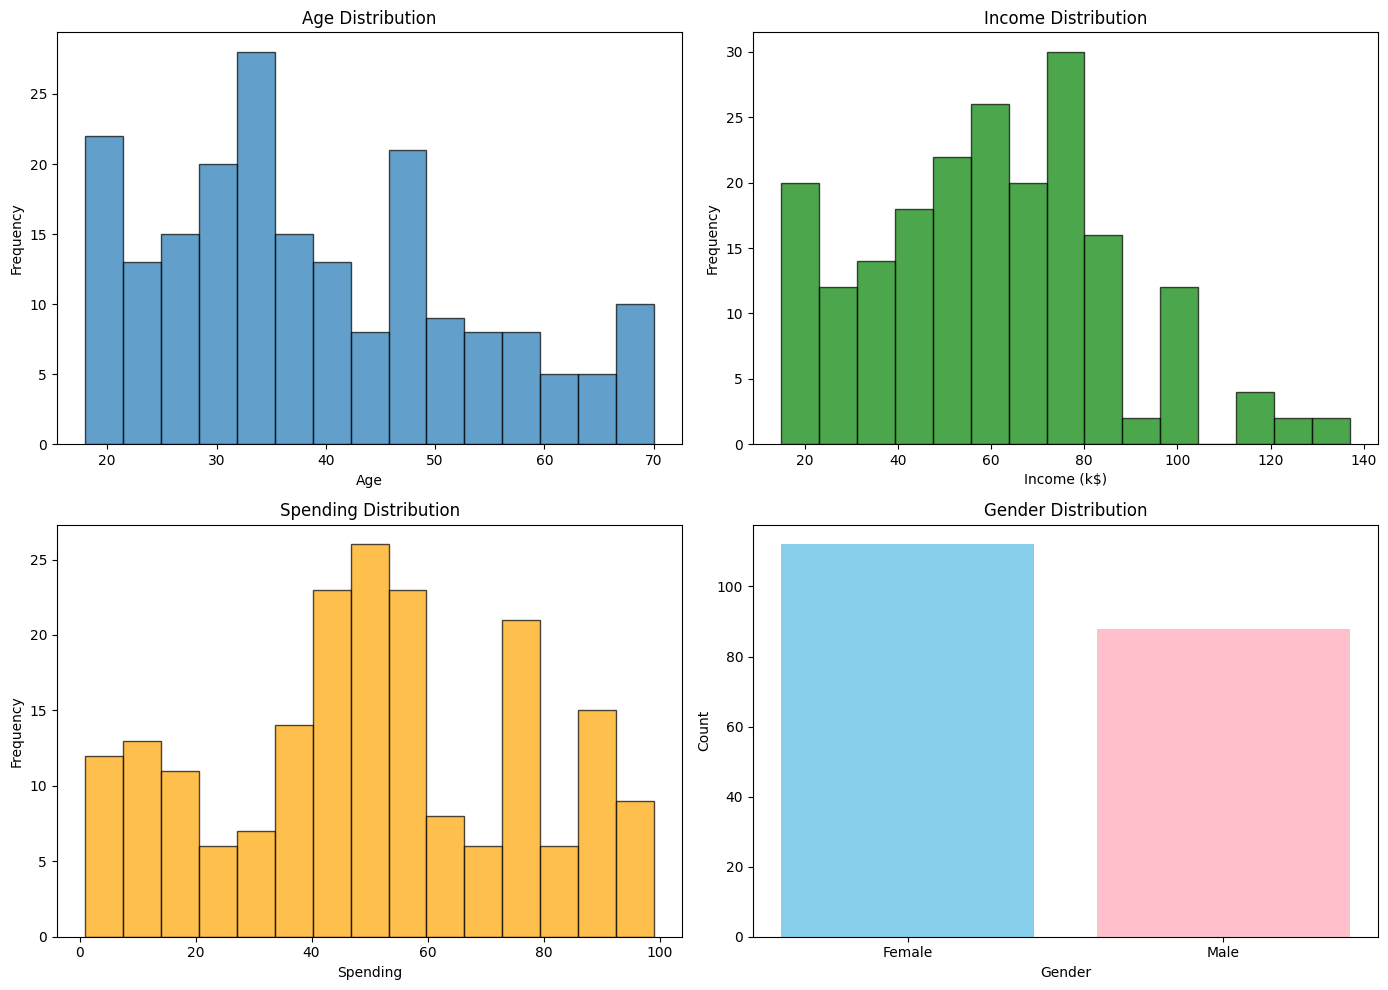

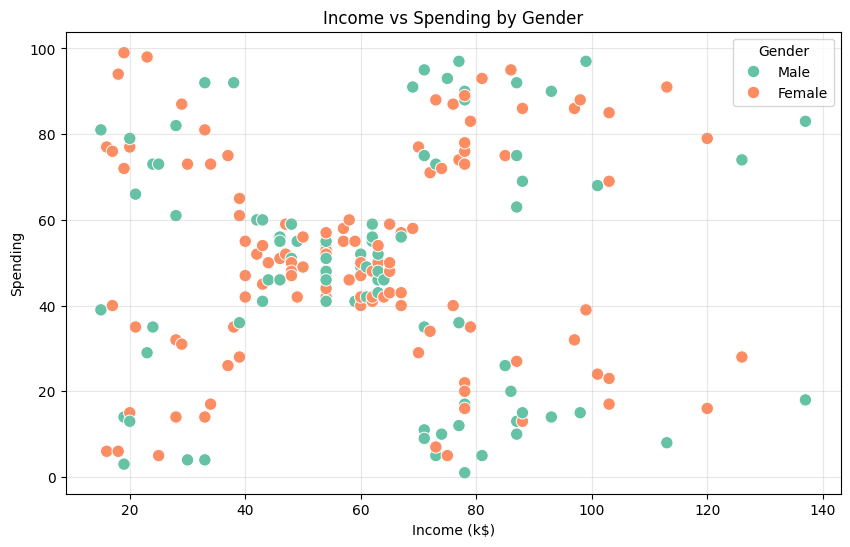

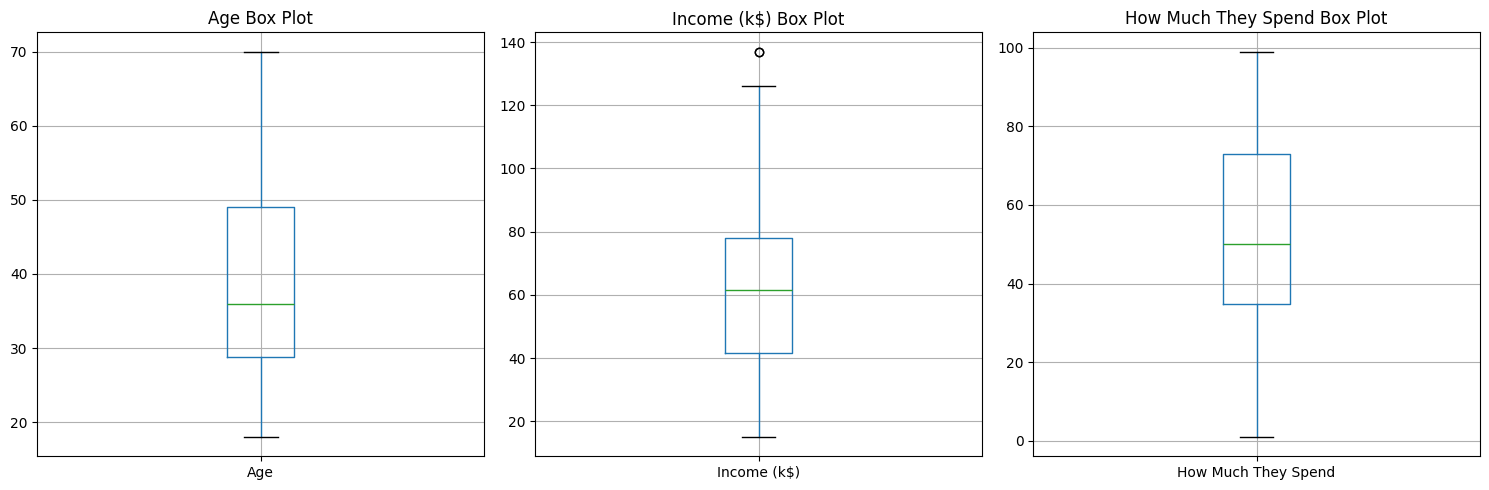

In [2]:
print("\n" + "="*50)
print("EXPLORATORY DATA ANALYSIS")
print("="*50)

print("Dataset Information:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

print("\nMissing values:")
print(df.isnull().sum())

# Data Visualization
# Histograms
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df['Age'], bins=15, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Age Distribution')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].hist(df['Income (k$)'], bins=15, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_title('Income Distribution')
axes[0, 1].set_xlabel('Income (k$)')
axes[0, 1].set_ylabel('Frequency')

axes[1, 0].hist(df['How Much They Spend'], bins=15, edgecolor='black', alpha=0.7, color='orange')
axes[1, 0].set_title('Spending Distribution')
axes[1, 0].set_xlabel('Spending')
axes[1, 0].set_ylabel('Frequency')

gender_counts = df['Gender'].value_counts()
axes[1, 1].bar(gender_counts.index, gender_counts.values, color=['skyblue', 'pink'])
axes[1, 1].set_title('Gender Distribution')
axes[1, 1].set_xlabel('Gender')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Scatter plot: Income vs Spending
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Income (k$)', y='How Much They Spend', 
                hue='Gender', palette='Set2', s=80)
plt.title('Income vs Spending by Gender')
plt.xlabel('Income (k$)')
plt.ylabel('Spending')
plt.grid(True, alpha=0.3)
plt.show()

# Box plots for outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, col in enumerate(['Age', 'Income (k$)', 'How Much They Spend']):
    df.boxplot(column=col, ax=axes[idx])
    axes[idx].set_title(f'{col} Box Plot')
plt.tight_layout()
plt.show()

## Section 3: Data Preprocessing

In [3]:
print("\n" + "="*50)
print("DATA PREPROCESSING & FEATURE ENGINEERING")
print("="*50)

# Select features for clustering
features = df[['Age', 'Income (k$)', 'How Much They Spend']].copy()
print(f"Features selected: {features.columns.tolist()}")

# Create Spending to Income Ratio
df['Spending_Income_Ratio'] = df['How Much They Spend'] / df['Income (k$)']
print("Created new feature: Spending_Income_Ratio")

# Scale features using StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
print("Features scaled successfully!")


DATA PREPROCESSING & FEATURE ENGINEERING
Features selected: ['Age', 'Income (k$)', 'How Much They Spend']
Created new feature: Spending_Income_Ratio
Features scaled successfully!


## Section 4: Feature Engineering

# Create a new feature: Spending to Income Ratio

In [4]:
print("\n" + "="*50)
print("FEATURE ENGINEERING")
print("="*50)

# Create Spending to Income Ratio
df['Spending_Income_Ratio'] = df['How Much They Spend'] / df['Income (k$)']
print("Created new feature: Spending_Income_Ratio")
print("\nSample of new feature:")
print(df[['Income (k$)', 'How Much They Spend', 'Spending_Income_Ratio']].head())

# Update features to include new feature
features_with_ratio = df[['Age', 'Income (k$)', 'How Much They Spend', 'Spending_Income_Ratio']]
scaled_features_final = scaler.fit_transform(features_with_ratio)
print(f"\nFinal feature shape (with new feature): {scaled_features_final.shape}")


FEATURE ENGINEERING
Created new feature: Spending_Income_Ratio

Sample of new feature:
   Income (k$)  How Much They Spend  Spending_Income_Ratio
0           15                   39               2.600000
1           15                   81               5.400000
2           16                    6               0.375000
3           16                   77               4.812500
4           17                   40               2.352941

Final feature shape (with new feature): (200, 4)


## Section 5: Model Building


CLUSTERING MODEL BUILDING
Determining optimal k using Elbow Method and Silhouette Score...


  File "c:\Users\edrin\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\edrin\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\edrin\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\edrin\anaconda3\Lib\subprocess.

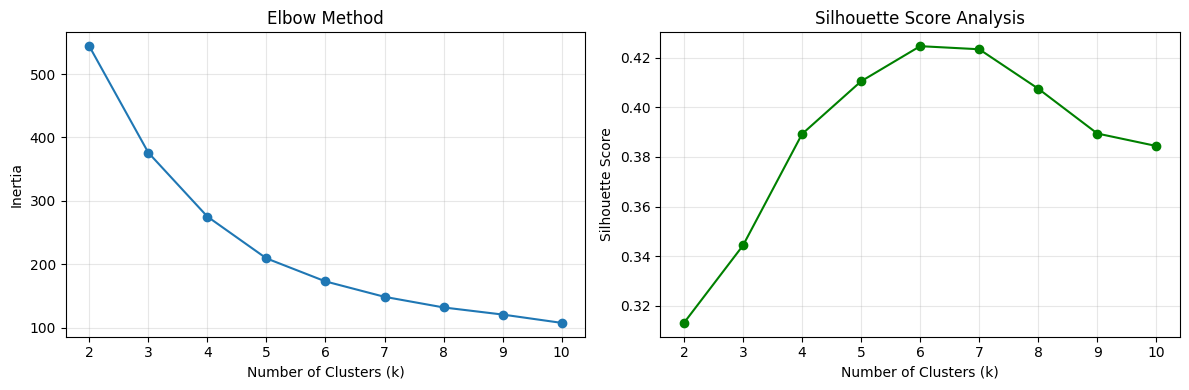


Optimal number of clusters (k): 6
Based on highest silhouette score: 0.425 at k=6

Applying K-Means Clustering...
K-Means Cluster Distribution:
KMeans_Cluster
0    45
1    20
2    34
3    23
4    39
5    39
Name: count, dtype: int64

Applying Hierarchical Clustering...
Hierarchical Cluster Distribution:
Hierarchical_Cluster
0    26
1    35
2    54
3    39
4    28
5    18
Name: count, dtype: int64


In [5]:
print("\n" + "="*50)
print("CLUSTERING MODEL BUILDING")
print("="*50)

# 5.1 Determine Optimal k using Elbow Method and Silhouette Score
print("Determining optimal k using Elbow Method and Silhouette Score...")

inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    # KMeans model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features_final)
    inertias.append(kmeans.inertia_)
    
    # Silhouette score
    labels = kmeans.labels_
    silhouette_avg = silhouette_score(scaled_features_final, labels)
    silhouette_scores.append(silhouette_avg)

# Plot Elbow Method
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True, alpha=0.3)

# Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o', color='green')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score Analysis')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Determine optimal k
optimal_k = silhouette_scores.index(max(silhouette_scores)) + 2
print(f"\nOptimal number of clusters (k): {optimal_k}")
print(f"Based on highest silhouette score: {max(silhouette_scores):.3f} at k={optimal_k}")

# 5.2 Apply K-Means Clustering
print("\nApplying K-Means Clustering...")
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(scaled_features_final)
df['KMeans_Cluster'] = kmeans_labels

print("K-Means Cluster Distribution:")
print(df['KMeans_Cluster'].value_counts().sort_index())

# 5.3 Apply Hierarchical Clustering
print("\nApplying Hierarchical Clustering...")
hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(scaled_features_final)
df['Hierarchical_Cluster'] = hierarchical_labels

print("Hierarchical Cluster Distribution:")
print(df['Hierarchical_Cluster'].value_counts().sort_index())

## Section 6: Model Evaluation


MODEL EVALUATION

Model Comparison (Silhouette Score):
          Model  Silhouette Score
0       K-Means          0.424606
1  Hierarchical          0.404844


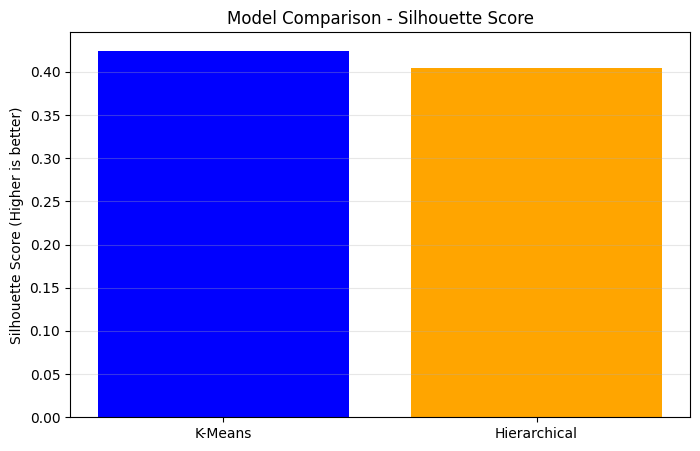


Best performing model: K-Means


In [6]:
# SECTION 6: Model Evaluation
print("\n" + "="*50)
print("MODEL EVALUATION")
print("="*50)

# Evaluate both models using silhouette score
results = []

for model_name, labels_col in [('K-Means', 'KMeans_Cluster'), 
                               ('Hierarchical', 'Hierarchical_Cluster')]:
    labels = df[labels_col]
    silhouette = silhouette_score(scaled_features_final, labels)
    
    results.append({
        'Model': model_name,
        'Silhouette Score': silhouette
    })

results_df = pd.DataFrame(results)
print("\nModel Comparison (Silhouette Score):")
print(results_df)

# Visual comparison
plt.figure(figsize=(8, 5))
plt.bar(results_df['Model'], results_df['Silhouette Score'], color=['blue', 'orange'])
plt.title('Model Comparison - Silhouette Score')
plt.ylabel('Silhouette Score (Higher is better)')
plt.grid(True, alpha=0.3, axis='y')
plt.show()

# Select best model
best_model = results_df.loc[results_df['Silhouette Score'].idxmax(), 'Model']
print(f"\nBest performing model: {best_model}")

## Section 7: Cluster Visualization

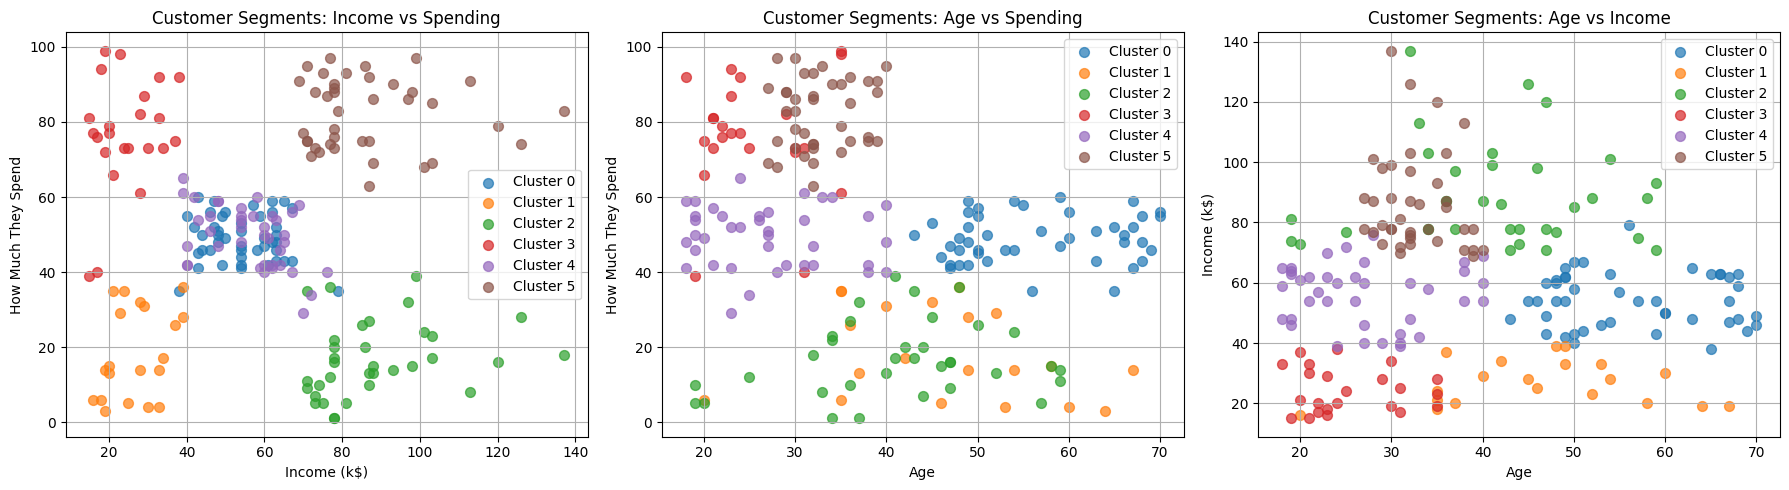

In [7]:
# Scatter plots showing clusters (using K-Means as best model)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Income vs Spending
for cluster in range(optimal_k):
    cluster_data = df[df['KMeans_Cluster'] == cluster]
    axes[0].scatter(cluster_data['Income (k$)'], 
                   cluster_data['How Much They Spend'],
                   label=f'Cluster {cluster}', alpha=0.7, s=50)
axes[0].set_xlabel('Income (k$)')
axes[0].set_ylabel('How Much They Spend')
axes[0].set_title('Customer Segments: Income vs Spending')
axes[0].legend()
axes[0].grid(True)

# Age vs Spending
for cluster in range(optimal_k):
    cluster_data = df[df['KMeans_Cluster'] == cluster]
    axes[1].scatter(cluster_data['Age'], 
                   cluster_data['How Much They Spend'],
                   label=f'Cluster {cluster}', alpha=0.7, s=50)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('How Much They Spend')
axes[1].set_title('Customer Segments: Age vs Spending')
axes[1].legend()
axes[1].grid(True)

# Age vs Income
for cluster in range(optimal_k):
    cluster_data = df[df['KMeans_Cluster'] == cluster]
    axes[2].scatter(cluster_data['Age'], 
                   cluster_data['Income (k$)'],
                   label=f'Cluster {cluster}', alpha=0.7, s=50)
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Income (k$)')
axes[2].set_title('Customer Segments: Age vs Income')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

## Section 8: Result Analysis

=== CLUSTER CHARACTERISTICS ===
                  Age  Income (k$)  How Much They Spend  Spending_Income_Ratio
KMeans_Cluster                                                                
0               56.33        54.27                49.07                   0.93
1               46.25        26.75                18.35                   0.69
2               41.26        88.50                16.76                   0.19
3               25.30        24.30                76.52                   3.37
4               26.92        56.21                49.54                   0.92
5               32.69        86.54                82.13                   0.98
=== CLUSTER SIZES ===
Cluster 0: 45 customers (22.5%)
Cluster 1: 20 customers (10.0%)
Cluster 2: 34 customers (17.0%)
Cluster 3: 23 customers (11.5%)
Cluster 4: 39 customers (19.5%)
Cluster 5: 39 customers (19.5%)
=== GENDER DISTRIBUTION BY CLUSTER (%) ===
Gender          Female   Male
KMeans_Cluster               
0                57

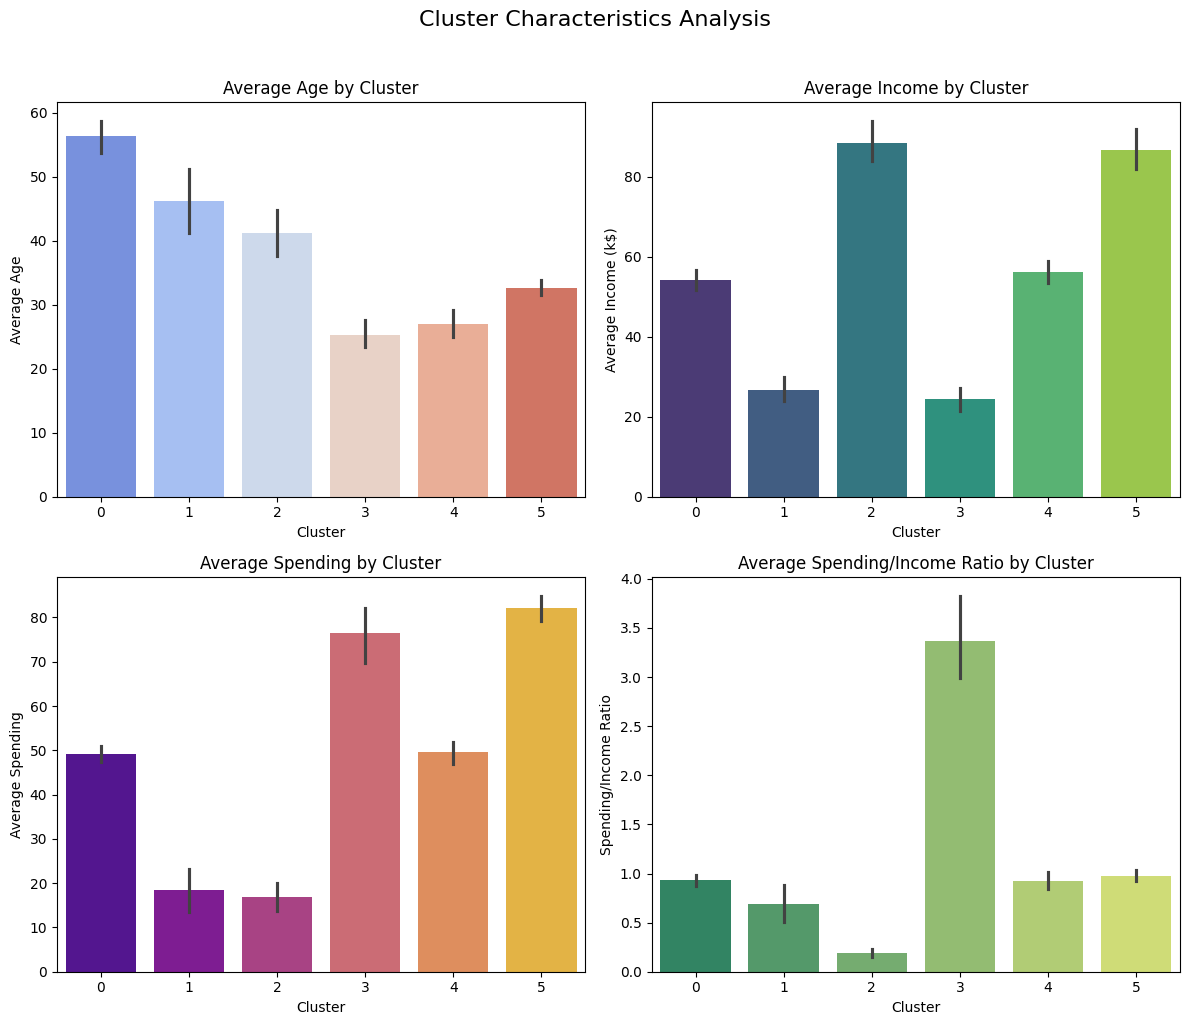

In [8]:
# Calculate mean values for each cluster
cluster_summary = df.groupby('KMeans_Cluster')[[
    'Age', 'Income (k$)', 'How Much They Spend', 'Spending_Income_Ratio'
]].mean().round(2)

print("=== CLUSTER CHARACTERISTICS ===")
print(cluster_summary)

# Calculate cluster sizes
cluster_sizes = df['KMeans_Cluster'].value_counts().sort_index()
cluster_percentages = (cluster_sizes / len(df) * 100).round(2)

print("=== CLUSTER SIZES ===")
for cluster in range(optimal_k):
    print(f"Cluster {cluster}: {cluster_sizes[cluster]} customers ({cluster_percentages[cluster]}%)")

# Analyze gender distribution in each cluster
gender_by_cluster = pd.crosstab(df['KMeans_Cluster'], df['Gender'], normalize='index') * 100
gender_by_cluster = gender_by_cluster.round(2)

print("=== GENDER DISTRIBUTION BY CLUSTER (%) ===")
print(gender_by_cluster)

# Create visualization of cluster characteristics
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Cluster Characteristics Analysis', fontsize=16, y=1.02)

# Age by cluster
sns.barplot(data=df, x='KMeans_Cluster', y='Age', ax=axes[0, 0], palette='coolwarm')
axes[0, 0].set_title('Average Age by Cluster')
axes[0, 0].set_xlabel('Cluster')
axes[0, 0].set_ylabel('Average Age')

# Income by cluster
sns.barplot(data=df, x='KMeans_Cluster', y='Income (k$)', ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Average Income by Cluster')
axes[0, 1].set_xlabel('Cluster')
axes[0, 1].set_ylabel('Average Income (k$)')

# Spending by cluster
sns.barplot(data=df, x='KMeans_Cluster', y='How Much They Spend', ax=axes[1, 0], palette='plasma')
axes[1, 0].set_title('Average Spending by Cluster')
axes[1, 0].set_xlabel('Cluster')
axes[1, 0].set_ylabel('Average Spending')

# Spending/Income Ratio by cluster
sns.barplot(data=df, x='KMeans_Cluster', y='Spending_Income_Ratio', ax=axes[1, 1], palette='summer')
axes[1, 1].set_title('Average Spending/Income Ratio by Cluster')
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('Spending/Income Ratio')

plt.tight_layout()
plt.show()